In [8]:
from src.util.dataset import GazeBaseDataset
from src.util.prepare import PrepConfig

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ds = GazeBaseDataset('data/GazeBase_v2_0')
cfg = PrepConfig()

In [9]:
ds.prepare('data/prepared', cfg=cfg)  # once

Preparing 1762 files: 100%|██████████| 88/88 [00:01<00:00, 55.39it/s]


Wrote 26,569,017 samples (0.4 GB, 7.4 h of signal) in 1,762 recordings -> data/prepared


'data/prepared'

In [18]:
train = ds.windows('data/prepared', 'train', normalization='sinusoidal', window=5000, stride=5000)

## VAE evaluation

Reconstruct held-out windows and compare against the originals. The numbers come from
`src.diagnostics`, so a sweep and this notebook score checkpoints identically.

Note: checkpoints trained before the `BlurPool1d` change cannot be loaded by the
current `VAE` (the encoder's downsampling layers differ). Use one from
`checkpoints/sweep/`.

In [19]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from src.vae import VAE, VAEConfig, loaders
from src.diagnostics import collect, report, deg, microsaccades, property_stats

CKPT = 'checkpoints/vae_selected.pt'

dev = 'cuda' if torch.cuda.is_available() else 'cpu'
ckpt = torch.load(CKPT, map_location=dev, weights_only=False)
cfg = VAEConfig(**ckpt['cfg'])

model = VAE(cfg).to(dev)
model.load_state_dict(ckpt['state_dict'])
model.eval()

window = ckpt['window']
train_loader, val_loader = loaders('data/GazeBase_v2_0', 'data/prepared',
                                   window=window, batch_size=32, workers=4)

print(f'window {window} -> latent ({cfg.latent_channels}, {window // cfg.downsample}), '
      f'{len(val_loader.dataset)} val windows on {dev}')

window 4992 -> latent (8, 312), 1080 val windows on cuda


In [20]:
x, xh, mu, sd = collect(model, train_loader, dev)
metrics = report(x, xh, mu, sd)

/home/pontus/Documents/Master's Thesis/thesis/.venv/lib/python3.12/site-packages/torch/utils/data/_utils/collate.py:285: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:206.)
  return collate([torch.as_tensor(b) for b in batch], collate_fn_map=collate_fn_map)
/home/pontus/Documents/Master's Thesis/thesis/.venv/lib/python3.12/site-packages/torch/utils/data/_utils/collate.py:285: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before co

reconstruction (4192 windows)
  mse                     0.0001
  mae                     0.0049
  var_explained           0.9781
  corr_vx                 0.9914
  corr_vy                 0.9907
  hf_retained             0.2841
  noise_floor_ratio       0.9421
properties               real   reconstruction
  rate                    2.329        2.750
  amp                     0.119        0.097
  peak_vel               10.173        8.880
  main_seq_slope          0.700        0.703
  noise_floor             1.044        0.990
latent  8/8 active, 5 informative (SNR>1), 3 high-frequency, kurtosis 56.1, scale_factor 1.489
  ch   KL/dim     SNR    lag1   hi/lo
   0    1.342    3.56   -0.65   23.06
   1    0.085    0.36   -0.45    5.81
   2    0.064    0.30   -0.08    1.20
   3    0.043    0.25   -0.39    5.37
   4    0.458    1.08   -0.62   15.35
   5    1.637    4.75   -0.21    2.22
   6    2.823   14.87    0.04    0.90
   7    2.733   13.44    0.05    0.88


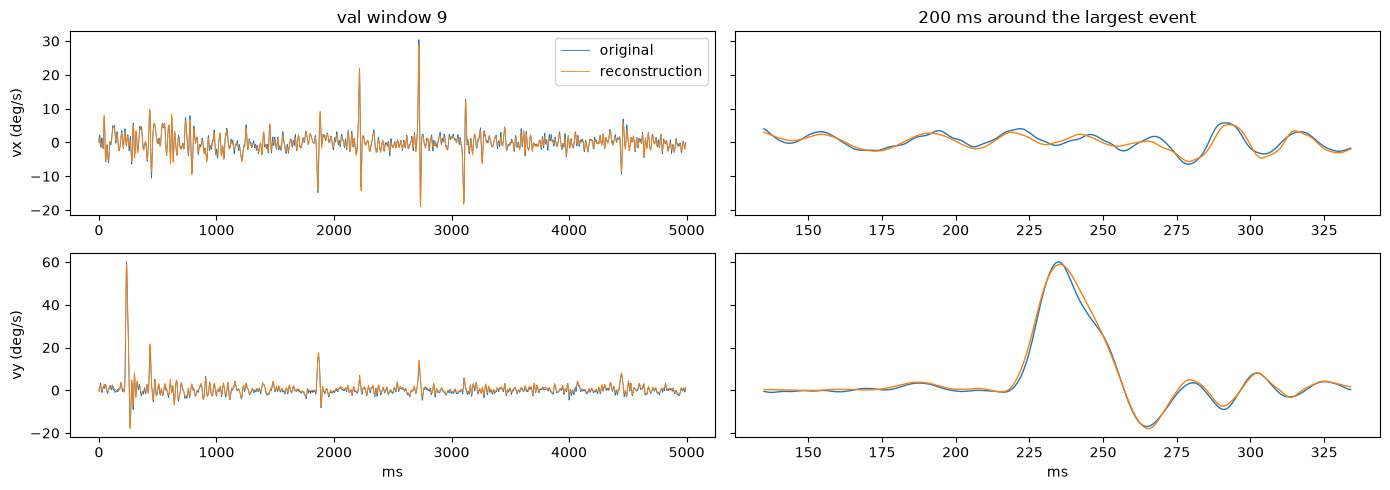

In [21]:
# Waveforms: the whole window, and a zoom on its largest event.
i = int(np.abs(x).max(axis=(1, 2)).argmax()) + 3
peak = int(np.abs(deg(x[i])).max(axis=0).argmax())
zoom = slice(max(0, peak - 100), peak + 100)
t = np.arange(window)

fig, axes = plt.subplots(2, 2, figsize=(14, 5), sharey='row')
for c, name in enumerate('xy'):
    axes[c, 0].plot(t, deg(x[i, c]), lw=.6, label='original')
    axes[c, 0].plot(t, deg(xh[i, c]), lw=.6, label='reconstruction')
    axes[c, 1].plot(t[zoom], deg(x[i, c, zoom]), lw=1)
    axes[c, 1].plot(t[zoom], deg(xh[i, c, zoom]), lw=1)
    axes[c, 0].set_ylabel(f'v{name} (deg/s)')
axes[0, 0].legend(loc='upper right')
axes[0, 0].set_title(f'val window {i}')
axes[0, 1].set_title('200 ms around the largest event')
axes[1, 0].set_xlabel('ms')
axes[1, 1].set_xlabel('ms')
fig.tight_layout()
plt.show()

(4192, 513)
(4192, 513)


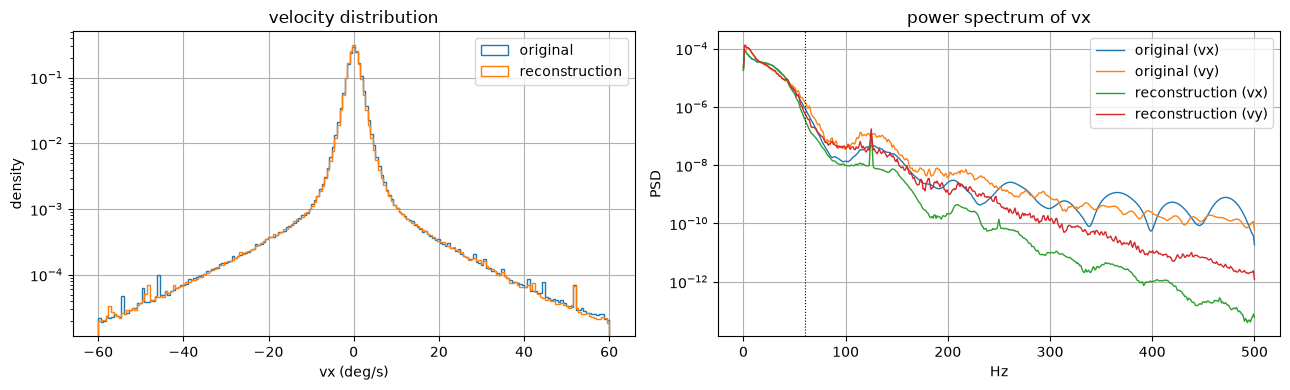

In [22]:
# Distribution and spectrum. hf_retained in the report above is this plot, above 60 Hz.
from scipy.signal import welch

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
bins = np.linspace(-60, 60, 200)
axes[0].hist(deg(x[:, 0]).ravel(), bins, histtype='step', density=True, label='original')
axes[0].hist(deg(xh[:, 0]).ravel(), bins, histtype='step', density=True, label='reconstruction')
axes[0].set(yscale='log', xlabel='vx (deg/s)', ylabel='density', title='velocity distribution')
axes[0].grid()
axes[0].legend()

for arr, lbl in ((x, 'original'), (xh, 'reconstruction')):
    f, p = welch(arr[:, 0], fs=1000, nperseg=1024, axis=-1)
    print(p.shape)
    axes[1].plot(f, p.mean(0), lw=1, label=f"{lbl} (vx)")
    f, p = welch(arr[:, 1], fs=1000, nperseg=1024, axis=-1)
    axes[1].plot(f, p.mean(0), lw=1, label=f"{lbl} (vy)")
    

axes[1].axvline(60, color='k', ls=':', lw=.8)
axes[1].set(xlabel='Hz', ylabel='PSD', title='power spectrum of vx')
axes[1].set_yscale("log", base=10)
axes[1].grid()
axes[1].legend()
fig.tight_layout()
plt.show()

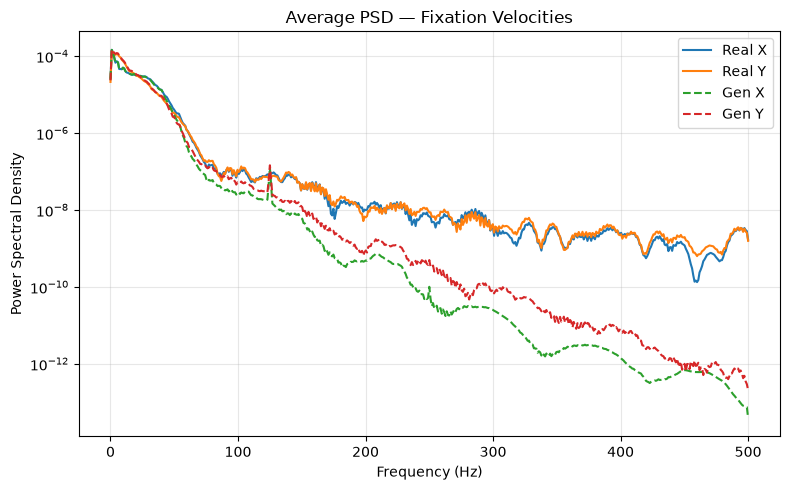

In [29]:
def plot_psd(real, gen, fs=1000, nperseg=1024):
    def avg_psd(data):
        N, C, L = data.shape
        psd_sum = np.zeros((C, nperseg // 2 + 1))
        for i in range(N):
            for c in range(C):
                f, Pxx = welch(data[i, c, :], fs=fs, nperseg=nperseg)
                psd_sum[c] += Pxx
        return f, psd_sum / N

    freqs, psd_real = avg_psd(real)
    _, psd_gen = avg_psd(gen)

    plt.figure(figsize=(8, 5))
    plt.semilogy(freqs, psd_real[0], label="Real X")
    plt.semilogy(freqs, psd_real[1], label="Real Y")
    plt.semilogy(freqs, psd_gen[0],  linestyle="--", label="Gen X")
    plt.semilogy(freqs, psd_gen[1],  linestyle="--", label="Gen Y")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Power Spectral Density")
    plt.title("Average PSD — Fixation Velocities")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_psd(x, xh, fs=1000)

### Microsaccades

The property the latent actually has to preserve. `microsacc` thresholds at
`VFAC x MSD`, i.e. relative to each trace's *own* noise floor, so a smoother
reconstruction gets a lower threshold and reports *more* small events. The noise
floor is printed alongside the counts so the two are read together.

  original         3656 events, 2.44 /s, amp 0.101 deg, peak vel 9.3 deg/s, slope 0.689, floor 1.04 deg/s
  reconstruction   4450 events, 2.97 /s, amp 0.083 deg, peak vel 7.9 deg/s, slope 0.689, floor 0.98 deg/s


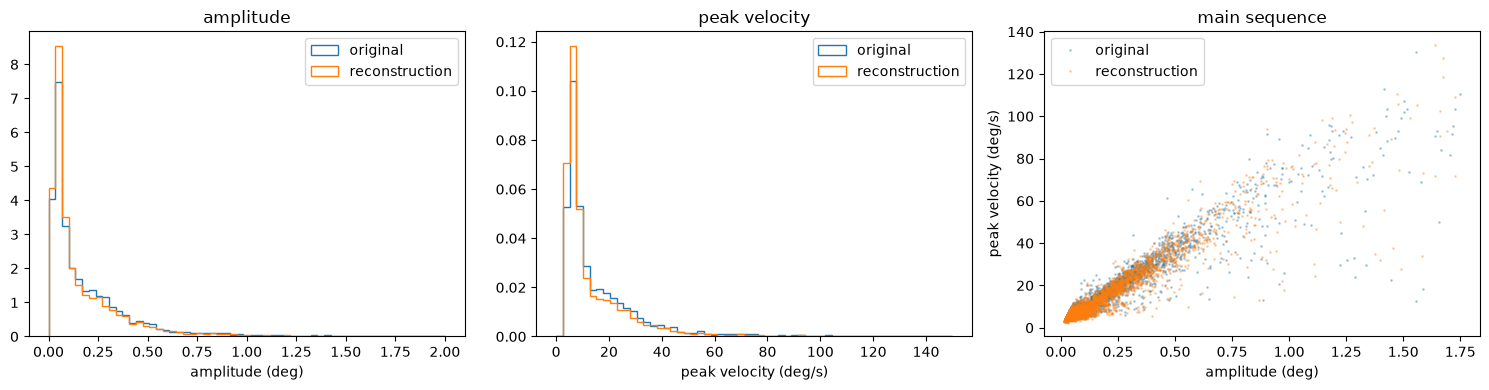

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for arr, lbl in ((x[:300], 'original'), (xh[:300], 'reconstruction')):
    s = np.concatenate([a for a in (microsaccades(w) for w in arr) if len(a)])
    st = property_stats(arr)
    print(f'  {lbl:15s} {len(s):5d} events, {st["rate"]:.2f} /s, '
          f'amp {st["amp"]:.3f} deg, peak vel {st["peak_vel"]:.1f} deg/s, '
          f'slope {st["main_seq_slope"]:.3f}, floor {st["noise_floor"]:.2f} deg/s')
    axes[0].hist(s[:, 6], np.linspace(0, 2, 60), histtype='step', density=True, label=lbl)
    axes[1].hist(s[:, 3], np.linspace(0, 150, 60), histtype='step', density=True, label=lbl)
    axes[2].plot(s[:, 6], s[:, 3], '.', ms=2, alpha=.3, label=lbl)
axes[0].set(xlabel='amplitude (deg)', title='amplitude')
axes[1].set(xlabel='peak velocity (deg/s)', title='peak velocity')
axes[2].set(xlabel='amplitude (deg)', ylabel='peak velocity (deg/s)', title='main sequence')
for a in axes:
    a.legend()
fig.tight_layout()
plt.show()